In [2]:
import glob

import numpy as np
import torch
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms
from retnext.transforms import AddChannelDim, ClipScaleVoxels
from retnext.modules import IntelliPore
from moxel.utils import voxels_from_file
from torchvision.transforms.v2 import Compose

In [3]:
import sys
sys.path.append('../')

In [4]:
from litmodules import MultiTaskLit

In [5]:
def save_activation(name):
    def hook(module, input, output):
        #activations[name] = output[0].detach()  # detach so no gradient tracking
        activations[name] = output.mean(0).detach()  # detach so no gradient tracking
    return hook

torch.Size([2, 1, 32, 32, 32])


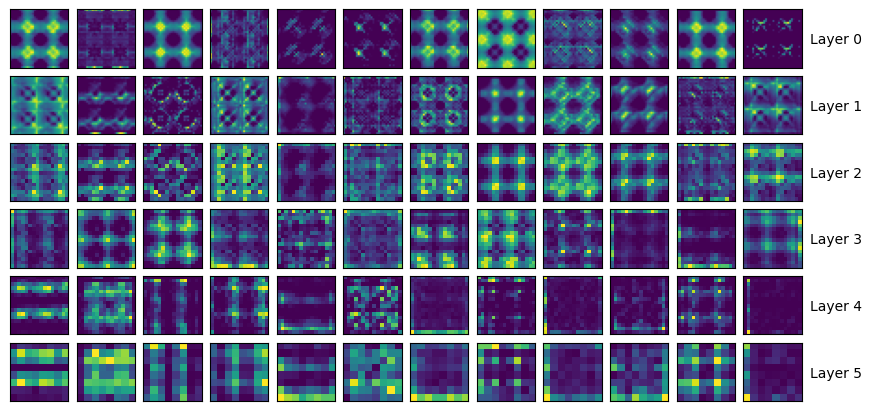

In [30]:
# Load the pretrained backbone
#backbone = RetNeXt(pretrained=True).backbone
backbone = MultiTaskLit.load_from_checkpoint(
    '../experiments/pretrain/initial_pretrain/lightning_logs/version_0/checkpoints/best.ckpt',
    map_location='cpu'
).backbone

transform = Compose([AddChannelDim(), ClipScaleVoxels()])

# Create input
images = []
#for matname in ['Cu-BTC', 'IRMOF-1', 'IRMOF-16', 'ZIF-8']:
for matname in ['Cu-BTC', 'IRMOF-1']:
#for matname in ['IRMOF-1']:
    cif = f'/home/asarikas/temp/CIFs/{matname}.cif'
    mof = read(cif)
    voxels = voxels_from_file(cif, 32, cubic_box=30)
    images.append(transform(torch.tensor(voxels).unsqueeze(0)))
    
#images = []
#for mat in glob.glob('../data/hCOF/voxels_data/*.npy')[:1_000]:
#    voxels = np.load(mat)
#    images.append(transform(torch.tensor(voxels).unsqueeze(0)))

x = torch.cat(images)
print(x.shape)

activations = {}
handles = []

for name, module in backbone.named_modules():
    if name == "":
        continue
    if isinstance(module, torch.nn.Sequential) or isinstance(module, torch.nn.MaxPool3d):
        h = module.register_forward_hook(save_activation(name))
        handles.append(h)

# Run forward pass to populate activations
backbone(x);

# Visualize feature maps
n_layers = 6
n_channels = 12

fig, axes = plt.subplots(n_layers, n_channels, layout='compressed', figsize=[10, 4])

for i, row_ax in enumerate(axes, start=0):
    row_ax[-1].yaxis.set_label_position('right')
    row_ax[-1].set_ylabel(f'Layer {i}', rotation='horizontal', y=0.6, labelpad=25)

    feat_map = activations[str(i)]  # C, H, D, W

    for j, col_ax in enumerate(row_ax):
        out = feat_map[j+12].sum(0)
        col_ax.set_xticks([])
        col_ax.set_yticks([])
        #col_ax.imshow(out, cmap='viridis', interpolation='gaussian')
        col_ax.imshow(out, cmap='viridis')